# 1. Introdução

## 1.1. Contexto do problema

## 1.2. Objetivo geral

## 1.3. Objetivos específicos

## 1.4. Breve configuração do ambiente

Antes de começar, peço que aguardem a instalação das dependências do projeto.

Após a instalação, será necessário reiniciar o embiente de execução.

Pede-se apenas que se clique novamente em "Executar tudo" após o término da instalação.

In [1]:
import os
from google.colab import runtime
first_run = 'pyproject.toml' not in os.listdir()

In [2]:
%%capture

!wget -nc 'https://github.com/ffserro/analise-de-dados-boas-praticas/raw/refs/heads/main/pyproject.toml'
!pip install -e .

In [3]:
from warnings import filterwarnings
filterwarnings('ignore')

if first_run: runtime.unassign()

del first_run

# 2. Base de Dados

A base de dados será carregada com a biblioteca Polars.

O motivo dessa escolha foi que esta biblioteca seria mais rápida do que o Pandas quando tratamos de DataFrames com mais de 1e6 linhas. Acontece que durante a limpeza o conjunto dos dados acabou ficando menor do que isso, mas como eu gostei de aprender sobre a biblioteca e achei a escrita bem mais elegante e mais fácil de vetorizar grandes transformações em comparação com o Pandas, decidi manter o uso predominante do Polars.

In [2]:
import polars as pl

df = (
    # pl.read_parquet([f'https://github.com/ffserro/analise-de-dados-boas-praticas/raw/refs/heads/main/database_2/metadata_part_{i:04d}.parquet' for i in range(1, 6)])
    # .join(
    #     pl.read_parquet([f'https://github.com/ffserro/analise-de-dados-boas-praticas/raw/refs/heads/main/database_2/textos_part_{i:04d}.parquet' for i in range(1, 24)]),
    #     on='id'
    # )
    
    pl.read_parquet('./database_2/metadata*.parquet')
    .join(
        pl.read_parquet('./database_2/textos*.parquet'),
        on='id'
    )
    .with_columns(
        pl.col('pubDate').str.to_date(),
        pl.col('pubName').str.head(3),  # Já com uma primeira limpeza porque existem algumas edições especiais que  tem um 'E' no final, como DO1E, por exemplo
    )
    .filter(
        pl.col('artCategory').str.to_lowercase().str.starts_with('ministério da defesa'),
        pl.col('artCategory').str.to_lowercase().str.contains(r'marinha|ex[ée]rcito|aeron[áa]utica')    # Como a proposta é fazer uma análise entre as três forças, não nos interessam os órgãos que não sejam subordinados ao Ministério da Defesa, nem as publicações do próprio Ministério.
    )
)

df.tail()

numberPage,pubName,name,artType,pubDate,artCategory,pdfPage,editionNumber,id,identifica,data,ementa,titulo,subtitulo,autores,idOficio,artClass,artSection,artSize,artNotes,highlightType,highlightPriority,highlight,idMateria,highlightimage,highlightimagename,texto
str,str,str,str,date,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""58""","""DO3""","""2025-12-30/11503645/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23469728""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503645""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23469728""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"
"""58""","""DO3""","""2025-12-30/11503746/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470217""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503746""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470217""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"
"""58""","""DO3""","""2025-12-30/11503765/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470438""","""EXTRATO DE CREDENCIAMENTO Nº 2…",null,null,null,null,null,"""11503765""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470438""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 2…"
"""58""","""DO3""","""2025-12-30/11503761/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470552""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503761""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470552""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"
"""58""","""DO3""","""2025-12-30/11503780/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470580""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503780""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470580""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"


In [3]:
df.shape

(1087705, 27)

## 2.1. Origem dos dados

Todos os dados utilizados foram extraídos da [Base de Dados de Publicações do DOU](https://in.gov.br/acesso-a-informacao/dados-abertos/base-de-dados).

O dicionário de dados ainda não foi disponibilizado segundo o próprio site, porém há uma breve explicação sobre a divisão dos documentos entre Seções.

Os documentos referentes às publicações estão no formato .xml, compactados em um arquivo .zip por ano, mês e seção.

## 2.2. Etapas de coleta

Toda a coleta foi realizada com um crawler básico, que está no repositório neste [link](https://github.com/ffserro/analise-de-dados-boas-praticas/blob/main/data_fetcher/pack_downloader.py).

Ele busca os links no site dos dados abertos do DOU, enviando um request com ano e mês. Precisa ser feito dessa forma, porque os links são gerados por seção, e se não contiverem informações dos cookies, tentar baixar os arquivos retorna um bad request.

Depois de resgatados os links, imediatamente se inicia o download do arquivo .zip em bytes para uma pasta local, onde é descompactado.

Após descompactar, eu fiz uma primeira filtragem para deletar todos os arquivos que não possuíssem em seu texto o termo "Ministério da Defesa".

A pasta com os arquivos baixados não pode ser armazenada no repositório porque possuía uma grande quantidade de arquivos, além do limite permitido pelo github. A solução foi já construir um dataset preliminar, no formato .parquet por ser mais leve, e salvá-lo particionado para que o git lfs permitisse o upload para o repositório. Essa etapa foi realizada por este [script](https://github.com/ffserro/analise-de-dados-boas-praticas/blob/main/bd_utils/bd_builder.py).

Durante a etapa de transformar os arquivos .xml em um dataframe, foram extraídas as informações tag por tag usando regex puro. Assim é a estrutura padrão de um arquivo:
```
<xml>
    <article id="" name="" idOficio="" pubName="" artType="" pubDate="" artClass="" artCategory="" artSize="" artNotes="" numberPage="" pdfPage="" editionNumber="" highlightType="" highlightPriority="" highlight="" highlightimage="" highlightimagename="" idMateria="">
        <body>
            <Identifica> </Identifica>
            <Data> </Data>
            <Ementa> </Ementa>
            <Titulo> </Titulo>
            <SubTitulo> </SubTitulo>
            <Texto> </Texto>
            <Autores>
                <assina> </assina>
                <cargo> </cargo>
            </Autores>
        </body>
        <Midias> </Midias>
    </article>
</xml>
```
Desta estrutura foram extraídos tanto os atributos da tag `article` quanto o conteúdo textual das tags `Identifica`, `Data`, `Ementa`, `Titulo`, `SubTitulo`, `Texto`, `Autores` e transformados em colunas deste dataframe.

## 2.3. Período analisado

São disponibilizados pela Base de Dados Abertos do DOU as publicações desde o ano de 2002 até o ano de 2026.

In [4]:
from plotly import express as px
import seaborn as sns
import matplotlib.pyplot as plt

fig = px.area(
    (
      df
      .group_by(pl.col('pubDate').dt.strftime('%Y/%m'), pl.col('pubName').str.head(3))
      .agg(pl.len())
      .sort('pubDate', 'pubName')
      .to_pandas()
    ),
    x='pubDate',
    y='len',
    color='pubName',
    title='Volume de artigos por mês e seção',
    labels={'len':'Volume', 'pubDate':'Mês de referência', 'pubName':'Seção'},
)
fig.show()

# plt.figure(figsize=(20,8))

# (
#     so.Plot(volume_por_ano.to_pandas(), 'pubDate', 'len', color='pubName').add(so.Area(alpha=.7), so.Stack())
# )

del fig

Pode ser observado uma quantidade de dados faltosos durante todo o ano de 2017.

Provavelmente a própria plataforma do DOU estava sendo reformulada durante esse período, porque se observam dados muito mais estruturados e consistentes a partir do ano de 2018.

Como exemplo mostro abaixo uma das colunas do dataframe que exemplifica essa melhor estruturação:

In [5]:
pl.concat(
    [
        df.filter(pl.col('pubDate').dt.year() < 2018).select(pl.col('artType').unique().alias('type_antes')),
        df.filter(pl.col('pubDate').dt.year() >= 2018).select(pl.col('artType').unique().alias('type_depois')),
    ],
    how='horizontal'
).drop_nulls().show(limit=20, fmt_str_lengths=50)

type_antes,type_depois
str,str
"""PORTARIA-SSIP/9-PENSÕES""","""Aviso de Anulação"""
"""RETITIFCAÇÃO""","""Portaria Conjunta"""
"""Profissão:""","""Extrato de Prorrogação de Ofício"""
"""Nº474""","""Ajuste"""
"""Nº485""","""Extrato de Comodato"""
"""DELIBERACAO""","""Extrato de Denúncia"""
"""Nº66""","""Aviso"""
"""PORTARIAS""","""Ato Regimental"""
"""7ª""","""Extrato de Concessão de Uso"""


Desta forma, por simplicidade e para limitar o escopo, vou considerar apenas os dados a partir do ano de 2018.

In [6]:
df = (
    df
    .filter(pl.col('pubDate').dt.year() >= 2018)
)

(
    df
    .select(
        pl.col('pubDate').min().alias('de'),
        pl.col('pubDate').max().alias('ate')
    )
)

de,ate
date,date
2018-03-07,2026-02-27


## 2.4. Limpeza e limitações

### 2.4.1. Valores nulos

Inicio a limpeza dos dados verificando a quantidade de valores nulos que cada uma das colunas contém, expressa aqui como razão entre a quantidade de nulos e o total de observações no conjunto de dados.

In [7]:
df.select(
    (pl.all().null_count() / pl.len() * 100).round(2).name.suffix("_null_pct")
).transpose(include_header=True).sort(by='column_0', descending=True).show(limit=15)

column,column_0
str,f64
"""titulo_null_pct""",100.0
"""autores_null_pct""",100.0
"""artSection_null_pct""",100.0
"""subtitulo_null_pct""",99.92
"""ementa_null_pct""",99.27
"""data_null_pct""",97.27
"""highlightimage_null_pct""",16.69
"""highlightimagename_null_pct""",16.69
"""highlightType_null_pct""",1.92


As colunas `titulo`, `autores`, `artSection`, `subtitulo`, `ementa` e `data`, embora pudessem conter dados muito úteis para análise, possuem uma quantidade insignificante de dados presentes, não podendo então serem consideradas. Removerei estas colunas do dataframe.

In [8]:
df = df.drop('titulo', 'autores', 'artSection', 'subtitulo', 'ementa', 'data')

### 2.4.2. Valores únicos

A próxima verificação é a quantidade de valores únicos por coluna. Algumas colunas naturalmente são compostas na sua totalidade por valores nulos, como é o exemplo do `id`, que identifica uma observação. No entanto, para uma análise dos dados, com exceção da coluna que seria a chave primária (`id`), ter outras colunas com dados únicos não permite extrair muita informação, já que não fornece um padrão de semelhança ou agrupamento das observações.

In [9]:
df.select(
    (pl.all().n_unique() / pl.len() * 100).round(2).name.suffix('_unique_pct')
).transpose(include_header=True).sort(by='column_0', descending=True).show(limit=15)

column,column_0
str,f64
"""id_unique_pct""",100.0
"""idMateria_unique_pct""",99.1
"""texto_unique_pct""",98.77
"""name_unique_pct""",81.69
"""idOficio_unique_pct""",65.17
"""identifica_unique_pct""",48.87
"""artClass_unique_pct""",32.65
"""pdfPage_unique_pct""",9.72
"""pubDate_unique_pct""",0.39


No primeiro momento notei que `idMateria`, que me parece que deveria ter 100% de valores únicos, se repete algumas vezes. Por quê?

In [10]:
df.filter(pl.col('idMateria').is_duplicated() & ~pl.col('idMateria').is_null()).sort(by=['idMateria', 'numberPage'], descending=[True, False]).select('idMateria', 'numberPage', 'texto')

idMateria,numberPage,texto
str,str,str
"""23616869""","""15""","""ATA DA ASSEMBLÉIA GERAL EXTRAO…"
"""23616869""","""18""","""Seção VII Competências do Pres…"
"""23591548""","""18""","""PORTARIA DIRENS/DCR Nº 1.018, …"
"""23591548""","""21""","""Art.98 O candidato menor de id…"
"""23591548""","""24""","""CAPÍTULO VI RECURSOS Art. 218 …"
…,…,…
"""10632282""","""27""","""CAPÍTULO VIII DO EXAME DE HABI…"
"""10632282""","""29""","""I - realizar, no prazo previst…"
"""10632282""","""31""","""_____. Estado Maior do Exércit…"


Algumas matérias, por serem mais extensas, tiveram seu texto ocupando mais do que uma página da publicação do Diário Oficial daquela data, por isso o texto aparece partido.

Abaixo, eu restituo os fragmentos dos textos ao seu preâmbulo, unificando sob uma observação. Espera-se com isso que a coluna `idMateria` se torne uma coluna de valores únicos.

In [11]:
df = (
    df
    .select(pl.all().exclude('texto'))
    .sort(by=['idMateria', 'numberPage'], descending=[True, False])
    .unique('idMateria', keep='first')
    .join(
        (
            df
            .sort(by=['idMateria', 'numberPage'], descending=[True, False])
            .group_by('idMateria')
            .agg(pl.col('texto').str.join('\n'))
        ), on='idMateria'
    )
)

Primeiro foi criado um dataframe sem a coluna `texto` ao qual foram reintegrados os textos devidamente concatenados.

In [12]:
df.select(
    (pl.all().n_unique() / pl.len() * 100).round(2).name.suffix('_unique_pct')
).transpose(include_header=True).sort(by='column_0', descending=True).show(limit=15)

column,column_0
str,f64
"""id_unique_pct""",100.0
"""idMateria_unique_pct""",100.0
"""texto_unique_pct""",98.84
"""name_unique_pct""",81.89
"""idOficio_unique_pct""",65.73
"""identifica_unique_pct""",49.21
"""artClass_unique_pct""",32.74
"""pdfPage_unique_pct""",9.26
"""pubDate_unique_pct""",0.39


Assim, os identificadores de matéria se tornaram únicos, em mesma quantidade que os identificadores dos documentos.

In [13]:
(
    df
    .select(
        pl.col('idMateria').n_unique().alias('contagem_materias'),
        pl.col('id').n_unique().alias('contagem_documentos')
    )
)

contagem_materias,contagem_documentos
u32,u32
506666,506666


Não havendo mais necessidade de possuir dois identificadores diferentes, e como conhecer o número da página que contém a publicação não é mais útil, as duas colunas serão removidas.

In [14]:
df = (
    df.drop('idMateria', 'numberPage')
)

Agora eu quero saber porque é que os nomes dos documentos e os identificadores dos ofícios não são únicos.

In [15]:
df.sort(by=['pubDate', 'name']).filter(pl.col('name').is_duplicated()).select('name').show(limit=15, fmt_str_lengths=500)

name
str
"""##Ata"""
"""21. Texto para publicação no INC"""
"""ATO Extrato de Registro de Preço"""
"""Aviso de Credenciamento"""
"""Aviso de notificação de abertura"""
"""Aviso de notificação de abertura"""
"""Aviso de penalidade"""
"""EXTRATO DE TERMO ADITIVO"""
"""Extrato Aviso de Penalidade _Rog"""


Os nomes dos documentos não são padronizados e parece que eles contém as mesmas informações que a coluna `identifica`. Vejamos se temos mais sorte com a coluna `idOficio`.

In [16]:
df.sort(by=['idOficio', 'pubDate']).filter(pl.col('idOficio').is_duplicated()).select('pubDate', 'idOficio').unique().show(limit=15)

pubDate,idOficio
date,str
2024-07-22,"""10466275"""
2018-10-29,"""5027897"""
2026-02-20,"""11587220"""
2022-10-05,"""9143714"""
2023-03-13,"""9461571"""
2025-06-13,"""11083712"""
2020-12-24,"""6175527"""
2021-03-17,"""6299837"""
2021-11-04,"""6733262"""


Parece que todos os valores de `idOficio` duplicados possuem uma única `pubDate` comum. Vou verificar se isso está relacionado com o nome.

In [17]:
df.filter(pl.col('idOficio')=='4704719').select('idOficio', 'name', 'texto').show(fmt_str_lengths=500)

idOficio,name,texto
str,str,str
"""4704719""","""PORT497-2018-DPMM-TRRM""","""PORTARIA Nº 497/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"
"""4704719""","""PORT499-2018-DPMM-TRRM""","""PORTARIA Nº 499/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"
"""4704719""","""PORT496-2018-DPMM-TRRM""","""PORTARIA Nº 496/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"
"""4704719""","""PORT498-2018-DPMM-TRRM""","""PORTARIA Nº 498/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"


É isso.

Os documentos são enviados pelas organizações em lotes para serem publicados. Estes documentos devem ser encaminhados por um Ofício, que agrega um ou mais documentos que são publicados no mesmo dia. Entendi o motivo de não possuir apenas dados únicos, mas o `idOficio` ainda não me permite vislumbrar uma aplicação direta dos seus dados. Por isso será retirado do dataframe.

In [18]:
df = df.drop('idOficio')

Agora vamos descobrir por que a coluna `identifica`, que também soa como uma variável de identidade, não possui apenas valores únicos.

In [19]:
df.sort(by=['pubDate', 'identifica']).filter(pl.col('identifica').is_duplicated()).select('identifica').unique().show(limit=15, fmt_str_lengths=500)

identifica
str
"""EXTRATO DE TERMO ADITIVO Nº 1/2022 - UASG 160129 - ESA"""
"""EXTRATO DE TERMO ADITIVO Nº 1/2022 - UASG 160336 - D.F"""
"""AVISO DE REVOGAÇÃO PREGÃO Nº 2/2018"""
"""PORTARIA Nº 68 - REFM - SSVM.3/SAP/1-RIO/SSVM/1, de 8 de agosto de 2022"""
"""EXTRATO DE CONTRATO Nº 5/2023 - UASG 160085"""
"""EXTRATO DE APOSTILAMENTO Nº 2/2024 - UASG 160525"""
"""EXTRATO DE CONTRATO Nº 93/2024 - UASG 168005"""
"""EXTRATO DE CREDENCIAMENTO Nº 61/2023 - UASG 783330"""
"""EXTRATO DE TERMO ADITIVO Nº 4/2022 - UASG 160437"""


A primeira vista é ruim. Os valores de `identifica` não são padronizados. Possuem alguns valores genéricos, e outros valores específicos que não deveriam ser duplicados, como o mesmo número de contrato do mesmo ano para a mesma uasg.

In [20]:
df.filter(pl.col('identifica')=='AVISO DE LICITAÇÃO').select('identifica', 'name', 'texto').show(fmt_str_lengths=500)

identifica,name,texto
str,str,str
"""AVISO DE LICITAÇÃO""","""2021-03-19/6307183/siasgnet_1337""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 13/2021 - UASG 120636 Nº Processo: 67532.002671/2019. Objeto: Cessão de uso mercearia do ciaar. Total de Itens Licitados: 146. Edital: 22/03/2021 das 08h00 às 11h30 e das 13h30 às 16h00. Endereço: Av Brigadeiro Eduardo Gomes S/n, Vila Asas - Lagoa Santa/MG ou https://www.gov.br/compras/edital/120636-5-00013-2021. Entrega das Propostas: a partir de 22/03/2021 às 08h00 no site www.gov.br/compras. Abertura das Propostas: 01/04/2021 às 14h00 no site www.gov.br…"
"""AVISO DE LICITAÇÃO""","""2021-08-26/6602046/siasgnet_1378""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 4/2021 - UASG 160058 Nº Processo: 64561005581202136. Objeto: Contratação de empresas para, sob demanda, executar serviços de desinsetização, desratização, limpeza de caixa d'água e hidrojateamento a serem executados nas instalações do 32º Grupo de Artilharia de Campanha, Bateria Caiena e demais unidades participantes, conforme condições, quantidades, exigências e estimativas.. Total de Itens Licitados: 6. Edital: 30/08/2021 das 09h30 às 11h30 e das 13h30 à…"
"""AVISO DE LICITAÇÃO""","""2020-02-04/5714098/siasgnet_1240""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 1/2020 - UASG 160134 Nº Processo: 64181000394202050. Objeto: Eventual contratação de serviço de confecção de banners para instruções dos cursos e estágios do CIOpEsp. . Total de Itens Licitados: 2. Edital: 05/02/2020 das 08h00 às 11h40 e das 13h00 às 16h30. Endereço: Avenida do Forte, S/ Nr, Piratininga - Niterói, - Niterói/RJ ou www.comprasgovernamentais.gov.br/edital/160134-5-00001-2020. Entrega das Propostas: a partir de 05/02/2020 às 08h00 no site www.…"
"""AVISO DE LICITAÇÃO""","""2025-04-30/11002733/siasgnet_226""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 90011/2025 - UASG 120643 Nº Processo: 67273008605202495. Objeto: Republicação para aquisição de materiais de consumo de alvenaria e marcenaria. Total de Itens Licitados: 25. Edital: 05/05/2025 das 09h00 às 12h00 e das 13h00 às 17h00. Endereço: Rod Rst - 287 Km 240 - S/n Cx Pst 341, Camobi - Santa Maria/RS ou https://www.gov.br/compras/edital/120643-5-90011-2025. Entrega das Propostas: a partir de 05/05/2025 às 09h00 no site www.gov.br/compras. Abertura das…"
"""AVISO DE LICITAÇÃO""","""2019-09-27/5520330/siasgnet_1205""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 3/2019 - UASG 160429 Nº Processo: 64386001862201973. Objeto: Eventual aquisição material de higiene e limpeza.. Total de Itens Licitados: 99. Edital: 30/09/2019 das 08h00 às 12h00 e das 13h30 às 17h00. Endereço: Rua Duque de Caxias, 926 - Centro, Centro - São Gabriel/RS ou www.comprasgovernamentais.gov.br/edital/160429-5-00003-2019. Entrega das Propostas: a partir de 30/09/2019 às 08h00 no site www.comprasnet.gov.br. Abertura das Propostas: 10/10/2019 às 0…"


In [21]:
df.filter(pl.col('identifica')=="EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006").select('identifica', 'name', 'texto').show(fmt_str_lengths=500)

identifica,name,texto
str,str,str
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-07-08/11127985/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 45/2024. Nº Processo: 2024/00395/168006. Inexigibilidade. Nº 90017/2024. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 29.422.280/0001-08 - R DE C C ANDRADE CONSERVACAO E RESTAURO. Objeto: 1º termo aditivo ao contrato nº 45/2024/fjf cujo objeto é o acréscimo de 25 por cento no valor do contrato.. Vigência: 08/07/2025 a 04/02/2026. Valor Total Atualizado do Contrato: R$ 62.500,00. Data de Assinatura: 08/07…"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-03-11/10909053/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 26/2023. Nº Processo: 2023/00296/168006. Dispensa. Nº 216/2023. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 41.284.875/0001-40 - JND SOLUCOES TECNICAS EIRELI. Objeto: 1º termo aditivo ao contrato nº 26/2023/fjf - prorrogação do prazo de vigência do contrato por 12 meses. Vigência: 23/02/2025 a 22/02/2026. Valor Total Atualizado do Contrato: R$ 17.150,00. Data de Assinatura: 21/02/2025. (COMPRASNET 4.0 -…"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2026-01-05/11506254/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 59/2024. Nº Processo: 2024/00451/168006. Dispensa. Nº 90355/2024. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 05.013.308/0001-95 - AUT SISTEMAS DE AUTOMACAO LTDA. Objeto: 1º termo aditivo ao contrato 59/2024/fjf cujo objeto é a prorrogação do prazo de vigência por 12 meses.. Vigência: 10/02/2026 a 09/02/2027. Valor Total Atualizado do Contrato: R$ 200.586,05. Data de Assinatura: 19/12/2025. (COMPRASNET …"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-03-11/10908526/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 47/2024. Nº Processo: 2024/00258/168006. Pregão. Nº 90030/2024. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 24.276.464/0001-93 - SEGPREV SEGURANCA E SAUDE DO TRABALHADOR LTDA. Objeto: 1º termo aditivo ao contrato 47/2024/fjf cujo objeto é a alteração da cláusula nona - da subcontratação, com a condição de admitir a subcontratação parcial do objeto contratual.. Vigência: 19/02/2025 a 27/10/2025. Valor To…"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-12-17/11479292/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 28/2024. Nº Processo: 2024/00145-FJF. Pregão. Nº 90016/2024. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 18.683.397/0001-29 - M F FRAZAO CONSTRUCOES E SERVICOS LTDA. Objeto: 1º termo aditivo ao contrato nº 28/2024/fjf cujo objeto é a prorrogação do prazo por 12 meses e o acréscimo de 24,50 por cento no valor do contrato.. Vigência: 27/01/2026 a 26/01/2027. Valor Total Atualizado do Contrato: R$ 653.004,…"


Os valores genéricos de `identifica` fornecem o mesmo dado que a coluna `artType`, e os valores específicos acabam por repetir o cabeçalho do `texto` do documento. Por isso vou remover a coluna `identifica`, e aproveitando, excluo também a coluna `name` porque seus dados também constam no mesmo cabeçalho.

In [22]:
df =(
    df.drop('name', 'identifica')
)

Vamos descobrir porque a coluna `highlight`, que é um destaque do texto, possui tão poucos valores únicos.

In [23]:
df.group_by('highlight').agg(pl.len()).sort('len', descending=True)

highlight,len
str,u32
"""""",506004
"""Amazônia Azul Tecnologias de D…",3
"""Amazul convoca candidatos clas…",3
"""Lançado concurso de admissão a…",3
"""Aeronáutica estabelece condiçõ…",2
…,…
"""Alteradas normas para gestão d…",1
"""Retificado edital de concurso …",1
"""Aeronáutica aprova instruções …",1


In [24]:
df.filter(pl.col('highlight')!='')

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,artNotes,highlightType,highlightPriority,highlight,highlightimage,highlightimagename,texto
str,str,date,str,str,str,str,str,str,str,str,str,str,str,str,str
"""DO3""","""Retificação (de Edital)""",2021-08-12,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""152""","""530_20210812_13739677-1""","""00013:00044:00026:00000:00000:…","""24""","""""","""Concursos e Seleções""","""1""","""Exército realiza processo sele…","""""","""""","""EDITAL Nº 1, DE 5 DE AGOSTO DE…"
"""DO3""","""Edital""",2019-07-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""145""","""530_20190730_11884324""","""00011:00044:00025:00262:00007:…","""12""","""""","""Concursos e Seleções""","""2""","""IME realiza concurso de admiss…",null,null,"""EDITAL DE 30 DE JULHO DE 2019 …"
"""DO3""","""Edital de Processo Seletivo""",2023-11-09,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""213""","""530_20231109_21111674""","""00016:00012:00008:00048:00001:…","""24""","""""","""Concursos e Seleções""","""3""","""Agência Fluvial de Itacoatiara…","""""","""""","""EDITAL Nº 2, DE 7 DE NOVEMBRO …"
"""DO3""","""Retificação (de Edital)""",2020-10-16,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""199""","""530_20201016_13010149""","""00013:00045:00027:00005:00016:…","""12""","""""","""Concursos e Seleções""","""2""","""Veja retificações em editais d…","""""","""""","""edital SERVIÇO DE SELEÇÃO DO P…"
"""DO3""","""Resultado de Concurso Público""",2022-08-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""166""","""530_20220831_19847690""","""00013:00012:00009:00012:00000:…","""12""","""Subtítulo""","""Concursos e Seleções""","""2""","""MD convoca candidatos reservas…","""""","""""","""DEPARTAMENTO DE RECRUTAMENTO E…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DO1""","""Portaria""",2024-01-23,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""16""","""515_20240123_21339724""","""00016:00011:00007:00008:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""6""","""Aprovadas regras para aquisiçã…","""data:image/jpeg;base64,/9j/4AA…","""MD-Armas de Fogo-red.jpg""","""PORTARIA Nº 167 - COLOG/C Ex, …"
"""DO3""","""Retificação (de Edital)""",2020-06-17,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""114""","""530_20200617_12708799""","""00011:00045:00009:00012:00000:…","""12""","""""","""Concursos e Seleções""","""2""","""Retificado edital de seleção a…","""""","""""","""AVISO DE RETIFICAÇÃO CONCURSO …"
"""DO3""","""Edital de Convocação""",2022-10-25,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""203""","""530_20221025_20015561""","""00013:00012:00004:00000:00000:…","""12""","""""","""Concursos e Seleções""","""1""","""Amazônia Azul Tecnologias de D…","""""","""""","""EDITAL DE CONVOCAÇÃO Nº 12/202…"


A coluna `highlight` possui tão poucos valores únicos porque na verdade, o valor mais repetido é uma string vazia. Ou seja, são uma grande quantidade de valores ausentes.

Vejamos se o mesmo vale para toda a família das variáveis `highlight`.

In [25]:
df.filter(pl.col('highlightType')!='')

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,artNotes,highlightType,highlightPriority,highlight,highlightimage,highlightimagename,texto
str,str,date,str,str,str,str,str,str,str,str,str,str,str,str,str
"""DO3""","""Retificação (de Edital)""",2021-08-12,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""152""","""530_20210812_13739677-1""","""00013:00044:00026:00000:00000:…","""24""","""""","""Concursos e Seleções""","""1""","""Exército realiza processo sele…","""""","""""","""EDITAL Nº 1, DE 5 DE AGOSTO DE…"
"""DO3""","""Edital""",2019-07-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""145""","""530_20190730_11884324""","""00011:00044:00025:00262:00007:…","""12""","""""","""Concursos e Seleções""","""2""","""IME realiza concurso de admiss…",null,null,"""EDITAL DE 30 DE JULHO DE 2019 …"
"""DO3""","""Edital de Processo Seletivo""",2023-11-09,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""213""","""530_20231109_21111674""","""00016:00012:00008:00048:00001:…","""24""","""""","""Concursos e Seleções""","""3""","""Agência Fluvial de Itacoatiara…","""""","""""","""EDITAL Nº 2, DE 7 DE NOVEMBRO …"
"""DO3""","""Retificação (de Edital)""",2020-10-16,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""199""","""530_20201016_13010149""","""00013:00045:00027:00005:00016:…","""12""","""""","""Concursos e Seleções""","""2""","""Veja retificações em editais d…","""""","""""","""edital SERVIÇO DE SELEÇÃO DO P…"
"""DO3""","""Resultado de Concurso Público""",2022-08-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""166""","""530_20220831_19847690""","""00013:00012:00009:00012:00000:…","""12""","""Subtítulo""","""Concursos e Seleções""","""2""","""MD convoca candidatos reservas…","""""","""""","""DEPARTAMENTO DE RECRUTAMENTO E…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DO1""","""Portaria""",2024-01-23,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""16""","""515_20240123_21339724""","""00016:00011:00007:00008:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""6""","""Aprovadas regras para aquisiçã…","""data:image/jpeg;base64,/9j/4AA…","""MD-Armas de Fogo-red.jpg""","""PORTARIA Nº 167 - COLOG/C Ex, …"
"""DO3""","""Retificação (de Edital)""",2020-06-17,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""114""","""530_20200617_12708799""","""00011:00045:00009:00012:00000:…","""12""","""""","""Concursos e Seleções""","""2""","""Retificado edital de seleção a…","""""","""""","""AVISO DE RETIFICAÇÃO CONCURSO …"
"""DO3""","""Edital de Convocação""",2022-10-25,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""203""","""530_20221025_20015561""","""00013:00012:00004:00000:00000:…","""12""","""""","""Concursos e Seleções""","""1""","""Amazônia Azul Tecnologias de D…","""""","""""","""EDITAL DE CONVOCAÇÃO Nº 12/202…"


Aqui nos despedimos das variáveis de `highlight`.

In [26]:
df = (
    df.drop('highlight', 'highlightType', 'highlightPriority', 'highlightimage', 'highlightimagename')
)

In [27]:
df.head()

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,artNotes,texto
str,str,date,str,str,str,str,str,str,str,str
"""DO3""","""Edital""",2019-10-21,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""204""","""530_20191021_12117676""","""00011:00045:00008:00044:00006:…","""12""","""ok""","""EDITAL de 18 de outubro de 201…"
"""DO2""","""Portaria""",2024-02-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""24""","""529_20240202_21368869""","""00016:00011:00014:00007:00000:…","""12""","""""","""PORTARIA Nº 32- CMSE/C EX, DE …"
"""DO2""","""Portaria""",2021-07-22,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""137""","""529_20210722_13685130""","""00013:00044:00029:00010:00000:…","""12""","""""","""PORTARIA Nº 510-DCIPAS/SPC, DE…"
"""DO3""","""Aviso de Licitação-Pregão""",2018-06-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""108""","""10814638""","""00010:00008:00006:00019:00339:…","""8""","""""","""AVISO DE LICITAÇÃO PREGÃO ELET…"
"""DO3""","""Extrato de Contrato""",2020-08-03,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""147""","""530_20200803_12824228""","""00012:00044:00012:00017:00000:…","""12""","""""","""EXTRATO DE CONTRATO Nº 14/2020…"


Conheçamos a coluna `artNotes`.

In [28]:
df.filter(pl.col('artNotes')!='').select('artNotes').unique().show(limit=15, fmt_str_lengths=500)

artNotes
str
"""ok. deixa."""
"""OK - Qdo vier em forma de aviso e assinatura colocar AVISO."""
"""MD3 SINHÁ"""
"""FATIMA/CMP"""
"""SINHÁ MD1"""
"""dev mot 115"""
"""ok. a lei permite."""
"""ok. autorizado"""
"""OK - Os anexos não foram publicados no DOU de 18/4/2011. Como cita que estão sendo alterados também vou deixar sem publicá-los."""


O motivo para remoção desta variável dispensa explicações. Talvez a sua existência é que exija informações.

Acredito que ele atenda necessidades muito internas dos órgãos ou da própria Imprensa Nacional.

In [29]:
df = (
    df.drop('artNotes')
)

In [30]:
df.head()

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,texto
str,str,date,str,str,str,str,str,str,str
"""DO3""","""Edital""",2019-10-21,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""204""","""530_20191021_12117676""","""00011:00045:00008:00044:00006:…","""12""","""EDITAL de 18 de outubro de 201…"
"""DO2""","""Portaria""",2024-02-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""24""","""529_20240202_21368869""","""00016:00011:00014:00007:00000:…","""12""","""PORTARIA Nº 32- CMSE/C EX, DE …"
"""DO2""","""Portaria""",2021-07-22,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""137""","""529_20210722_13685130""","""00013:00044:00029:00010:00000:…","""12""","""PORTARIA Nº 510-DCIPAS/SPC, DE…"
"""DO3""","""Aviso de Licitação-Pregão""",2018-06-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""108""","""10814638""","""00010:00008:00006:00019:00339:…","""8""","""AVISO DE LICITAÇÃO PREGÃO ELET…"
"""DO3""","""Extrato de Contrato""",2020-08-03,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""147""","""530_20200803_12824228""","""00012:00044:00012:00017:00000:…","""12""","""EXTRATO DE CONTRATO Nº 14/2020…"


O que é a coluna `artSize` ?

In [31]:
df.select('artSize').unique()

artSize
str
"""8"""
"""12"""
"""24"""
"""25"""


O nome sugere que existam 4 formatos de tamanhos diferentes que podem ser alocados para determinada publicação nas nas edições do DOU. Vejamos se isso faz sentido.

In [32]:
(
    df
    .group_by('pubName', 'artSize')
    .agg(pl.len().alias('contagem'))
    .with_columns(
        (
            pl.col('contagem') / pl.col('contagem').sum().over('pubName') * 100
        ).round(2).alias('porcentagem')
    )
    .sort(by=['pubName', pl.col('artSize').str.to_integer()])
    .show(limit=-1)
)

pubName,artSize,contagem,porcentagem
str,str,u32,f64
"""DO1""","""8""",466,8.36
"""DO1""","""12""",4908,88.02
"""DO1""","""24""",200,3.59
"""DO1""","""25""",2,0.04
"""DO2""","""8""",6983,7.67
"""DO2""","""12""",83999,92.26
"""DO2""","""24""",68,0.07
"""DO3""","""8""",30969,7.55
"""DO3""","""12""",378448,92.3


É interessante saber que a maior parte dos documentos ocupa o tamanho padrão de 12, mas não vamos utilizar esses dados na nossa análise.

In [33]:
df = (
    df.drop('artSize')
)

Vamos inspecionar agora a coluna `editionNumber`

In [34]:
df.select('editionNumber').describe()

statistic,editionNumber
str,str
"""count""","""506666"""
"""null_count""","""0"""
"""mean""",null
"""std""",null
"""min""","""03"""
"""25%""",null
"""50%""",null
"""75%""",null
"""max""","""99"""


Desconfio de que o `editionNumber` seja uma contagem incremental das publicações diárias, ano a ano.

In [35]:
df.select('pubDate', 'editionNumber').unique().sort(by='pubDate').show(limit=15)

pubDate,editionNumber
date,str
2018-03-12,"""48"""
2018-03-13,"""49"""
2018-03-14,"""50"""
2018-03-15,"""51"""
2018-03-16,"""52"""
2018-03-19,"""53"""
2018-03-20,"""54"""
2018-03-21,"""55"""
2018-03-22,"""56"""


In [36]:
(
    df
    .group_by(pl.col('pubDate').dt.year().alias('ano'))
    .agg([
        pl.col('pubDate').n_unique().alias('contagem_dias'),
        pl.col('editionNumber').n_unique().alias('contagem_edicoes')
    ])
    .sort(by='ano')
)

ano,contagem_dias,contagem_edicoes
i32,u32,u32
2018,202,203
2019,250,252
2020,250,254
2021,249,253
2022,246,250
2023,247,248
2024,251,252
2025,238,240
2026,39,39


É isso. O número de edições se aproxima muito do número de dias. A contage não é exatamente igual porque por vezes é publicada uma edição especial, sendo rotulada de DO1E, DO2E ou DO3E, mas eu já fiz essa limpeza no carregamento dos dados, por isso não ficou explícito aqui.

Como o `editionNumber` não agrega mais informação do que o `pubDate`, será removido do dataframe.

In [37]:
df = df.drop('editionNumber')

A variável `pdfPage` é uma URL que redireciona para a publicação no formato .pdf, exatamente como foi publicada. Removerei do dataframe.

In [38]:
df = df.drop('pdfPage')

Abaixo, só para reordenar as colunas que restaram.

In [39]:
df = df.select('id', 'pubName', 'pubDate', 'artCategory', 'artType', 'artClass', 'texto')

In [40]:
df.head()

id,pubName,pubDate,artCategory,artType,artClass,texto
str,str,date,str,str,str,str
"""530_20191021_12117676""","""DO3""",2019-10-21,"""Ministério da Defesa/Comando d…","""Edital""","""00011:00045:00008:00044:00006:…","""EDITAL de 18 de outubro de 201…"
"""529_20240202_21368869""","""DO2""",2024-02-02,"""Ministério da Defesa/Comando d…","""Portaria""","""00016:00011:00014:00007:00000:…","""PORTARIA Nº 32- CMSE/C EX, DE …"
"""529_20210722_13685130""","""DO2""",2021-07-22,"""Ministério da Defesa/Comando d…","""Portaria""","""00013:00044:00029:00010:00000:…","""PORTARIA Nº 510-DCIPAS/SPC, DE…"
"""10814638""","""DO3""",2018-06-07,"""Ministério da Defesa/Comando d…","""Aviso de Licitação-Pregão""","""00010:00008:00006:00019:00339:…","""AVISO DE LICITAÇÃO PREGÃO ELET…"
"""530_20200803_12824228""","""DO3""",2020-08-03,"""Ministério da Defesa/Comando d…","""Extrato de Contrato""","""00012:00044:00012:00017:00000:…","""EXTRATO DE CONTRATO Nº 14/2020…"


Essa variável `artClass` parece classificar os documentos por alguma lógica. Estou interessado nela porque pode facilitar o processo de segmentar os documentos por assunto.

In [41]:
(
    df
    .group_by('artClass', 'pubName', 'artType')
    .agg(pl.len())
    .sort(by=[pl.col('len').sum().over('artClass'), 'artClass'], descending=[True, False])
).show(limit=20, fmt_str_lengths=100)

artClass,pubName,artType,len
str,str,str,u32
"""00016:00011:00013:00008:00004:00000:00000:00000:00000:00000:00053:00001""","""DO3""","""Extrato de Termo Aditivo""",1223
"""00016:00010:00011:00124:00000:00000:00000:00000:00000:00000:00079:00001""","""DO3""","""Aviso de Licitação-Leilão""",1
"""00016:00010:00011:00124:00000:00000:00000:00000:00000:00000:00079:00001""","""DO3""","""Aviso de Licitação""",1099
"""00016:00011:00001:00000:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",1099
"""00016:00012:00001:00000:00000:00000:00000:00000:00000:00000:00017:00000""","""DO1""","""Portaria""",1
"""00016:00012:00001:00000:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",1008
"""00016:00012:00027:00008:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",1000
"""00016:00011:00001:00002:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",960
"""00016:00011:00010:00007:00011:00000:00000:00000:00000:00000:00030:00001""","""DO3""","""Extrato de Concessão de Uso""",2


Talvez, olhando rápido, parece que o número na penúltima posição quando é 0017 se trata de uma Portaria, quando é 0079 é um Aviso, quando é 0032 é um Extrato. Mas nem sempre. Vou tentar achar algum sentido nisso.

Vou assumir que cada um dos valores separados por : no `artClass` seriam coordenadas em um espaço vetorial com 12 dimensões.

In [42]:
df_vetores = df.select(
    'id',
    (
        pl.col('artClass')
        .str.split(':')
        .list.eval(
            pl.element()
            .str.strip_chars('a')
            .cast(pl.Float64) * 1e-3
        )
    )
)

df_vetores

id,artClass
str,list[f64]
"""530_20191021_12117676""","[0.011, 0.045, … 0.0]"
"""529_20240202_21368869""","[0.016, 0.011, … 0.0]"
"""529_20210722_13685130""","[0.013, 0.044, … 0.028]"
"""10814638""","[0.01, 0.008, … 0.703]"
"""530_20200803_12824228""","[0.012, 0.044, … 0.476]"
…,…
"""530_20191122_12213855""","[0.011, 0.043, … 0.0]"
"""530_20240916_21972284""","[0.016, 0.011, … 0.0]"
"""530_20220315_14337798""","[0.013, 0.044, … 0.001]"


Vou explodir os valores dos caminhos hierárquicos do `artCategory` também.

A maioria segue até 5 níveis, partindo do Ministério da Defesa. Note que não existem 8, nem 9.

In [43]:
df.select(pl.col('artCategory').str.split('/').list.len()).group_by('artCategory').agg(pl.len()).sort('artCategory')

artCategory,len
u32,u32
2,514
3,42137
4,157938
5,223398
6,81681
7,996
10,2


Vou forçar todas essas variáveis suspeitas de possuírem alguma correlação para visualizar se alguma faz sentido. Abaixo estou improvisando dummies para as variáveis categóricas que eu vou tentar relacionar com o "vetor" do `artClass`.

In [44]:
artCategory_dummy = {v:k for k,v in enumerate(df.select('artCategory').unique().sort('artCategory').to_series().to_list())}
artType_dummy = {v:k for k,v in enumerate(df.select('artType').unique().sort('artType').to_series().to_list())}
preType_dummy = {v:k for k,v in enumerate(df.select(pl.col('artType').str.split(' ').list.first()).unique().sort('artType').to_series().to_list())}

C:\Users\INTEL\AppData\Local\Temp\ipykernel_35060\1633308293.py:19: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("artCategory").map_elements(lambda x: ...)
with this one instead:
  + pl.col("artCategory").replace_strict(artCategory_dummy)

  artCategory=pl.col('artCategory').map_elements(lambda x: artCategory_dummy[x], return_dtype=pl.Int32).cast(pl.Float64),
C:\Users\INTEL\AppData\Local\Temp\ipykernel_35060\1633308293.py:20: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("artType").map_elements(lambda x: ...)
with this one instead:
  + pl.col("artType").replace_strict(artType_dummy)

  artType=pl.col('artType').map_elements(lambda x: artType_dummy[x], return_dtype=

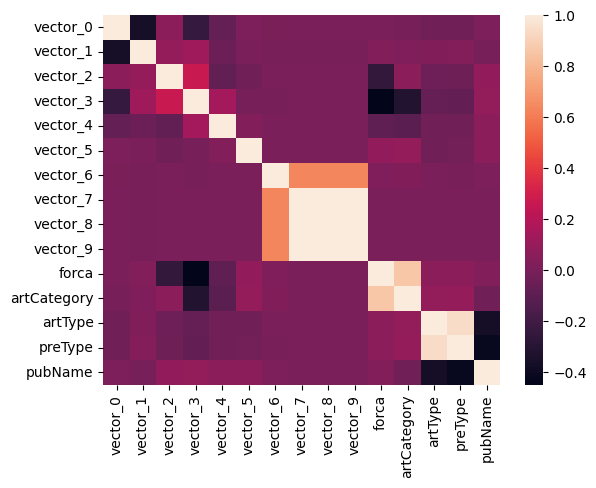

In [45]:
import polars.selectors as cs
from seaborn import heatmap

fig = plt.figure()
heatmap((
    df_vetores
    .with_columns(
        pl.col('artClass').list.to_struct(
            fields=[f'vector_{i}' for i in range(12)]
        )
    )
    .unnest('artClass')
    .join(
        df,
        on='id'
    )
    .with_columns(
        forca=pl.col('artCategory').str.split('/').list.slice(1,1).list.first().map_elements(lambda x: {'Comando da Aeronáutica':0, 'Comando da Marinha':1, 'Comando do Exército':2}[x], return_dtype=pl.Int32).cast(pl.Float64),
        artCategory=pl.col('artCategory').map_elements(lambda x: artCategory_dummy[x], return_dtype=pl.Int32).cast(pl.Float64),
        artType=pl.col('artType').map_elements(lambda x: artType_dummy[x], return_dtype=pl.Int32).cast(pl.Float64),
        pubName=pl.col('pubName').map_elements(lambda x: {'DO1':0, 'DO2':1, 'DO3':2}[x], return_dtype=pl.Int32).cast(pl.Float64),
        preType=pl.col('artType').str.split(' ').list.first().map_elements(lambda x: preType_dummy[x], return_dtype=pl.Int32).cast(pl.Float64)

    )
    .with_columns(
        (cs.float() - cs.float().min()) / (cs.float().max() - cs.float().min())
    )
).select(*[f'vector_{i}' for i in range(10)], 'forca', 'artCategory', 'artType', 'preType', 'pubName').to_pandas().corr())

fig.show()

del fig

Parece que não há nenhuma relação interessante.

As relações óbvias são do `vector_6` com os subsequentes, porque quando o desdobramento hierárquico chega até o nível 7, é muito provável que ele continue, pea contagem que fizemos.

Além disso, as relações entre `forca` e `artCategory`, já que `artCategory` contém a `forca`, `artType`, `preType` e `pubName` também era esperado.

A única relação que chama a atenção é a relação de `vector_3` com `forca`.

In [46]:
(
    df_vetores
    .with_columns(
        pl.col('artClass').list.to_struct(
            fields=[f'vector_{i}' for i in range(12)]
        )
    )
    .unnest('artClass')
    .join(
        df,
        on='id'
    )
    .with_columns(
        (cs.float() - cs.float().min()) / (cs.float().max() - cs.float().min()),
        forca=pl.col('artCategory').str.split('/').list.slice(1,1).list.first().map_elements(lambda x: {'Comando da Aeronáutica':0, 'Comando da Marinha':1, 'Comando do Exército':2}[x], return_dtype=pl.Int32),
        artCategory=pl.col('artCategory').map_elements(lambda x: artCategory_dummy[x], return_dtype=pl.Int32),
        pubName=pl.col('pubName').map_elements(lambda x: {'DO1':0, 'DO2':1, 'DO3':2}[x], return_dtype=pl.Int32)

    )
).group_by('vector_3', 'forca').agg(pl.len()).sort('vector_3')

del artCategory_dummy, artType_dummy, preType_dummy

C:\Users\INTEL\AppData\Local\Temp\ipykernel_35060\839766906.py:16: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("artCategory").map_elements(lambda x: ...)
with this one instead:
  + pl.col("artCategory").replace_strict(artCategory_dummy)

  artCategory=pl.col('artCategory').map_elements(lambda x: artCategory_dummy[x], return_dtype=pl.Int32),


Não existe uma relação tão significativa, até porque são muito valores diferentes de `vector_3` para apenas 3 `forca`.

Vou tentar mais um vez encontrar esse relacionamento, verificando se esses dados de `artClass` podem ser clusterizados de alguma forma.

In [47]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

df_vetores = df_vetores.with_columns(
    pl.Series(
        'vetor_reduzido',
        pipeline.fit_transform(
            np.vstack(
                df_vetores
                .select('artClass')
                .to_series()
                .to_numpy()
            )
        )
    )
)

del pipeline

In [48]:
df = df.with_columns(
    vetor=df_vetores.select('vetor_reduzido').to_series()
)

del df_vetores

In [49]:
df.head()

id,pubName,pubDate,artCategory,artType,artClass,texto,vetor
str,str,date,str,str,str,str,"array[f64, 2]"
"""530_20191021_12117676""","""DO3""",2019-10-21,"""Ministério da Defesa/Comando d…","""Edital""","""00011:00045:00008:00044:00006:…","""EDITAL de 18 de outubro de 201…","[-0.021562, -0.837325]"
"""529_20240202_21368869""","""DO2""",2024-02-02,"""Ministério da Defesa/Comando d…","""Portaria""","""00016:00011:00014:00007:00000:…","""PORTARIA Nº 32- CMSE/C EX, DE …","[-0.007067, 1.471448]"
"""529_20210722_13685130""","""DO2""",2021-07-22,"""Ministério da Defesa/Comando d…","""Portaria""","""00013:00044:00029:00010:00000:…","""PORTARIA Nº 510-DCIPAS/SPC, DE…","[-0.015052, -0.783736]"
"""10814638""","""DO3""",2018-06-07,"""Ministério da Defesa/Comando d…","""Aviso de Licitação-Pregão""","""00010:00008:00006:00019:00339:…","""AVISO DE LICITAÇÃO PREGÃO ELET…","[-0.018126, -0.070529]"
"""530_20200803_12824228""","""DO3""",2020-08-03,"""Ministério da Defesa/Comando d…","""Extrato de Contrato""","""00012:00044:00012:00017:00000:…","""EXTRATO DE CONTRATO Nº 14/2020…","[-0.019073, -0.581346]"


C:\Users\INTEL\AppData\Local\Temp\ipykernel_35060\243166205.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


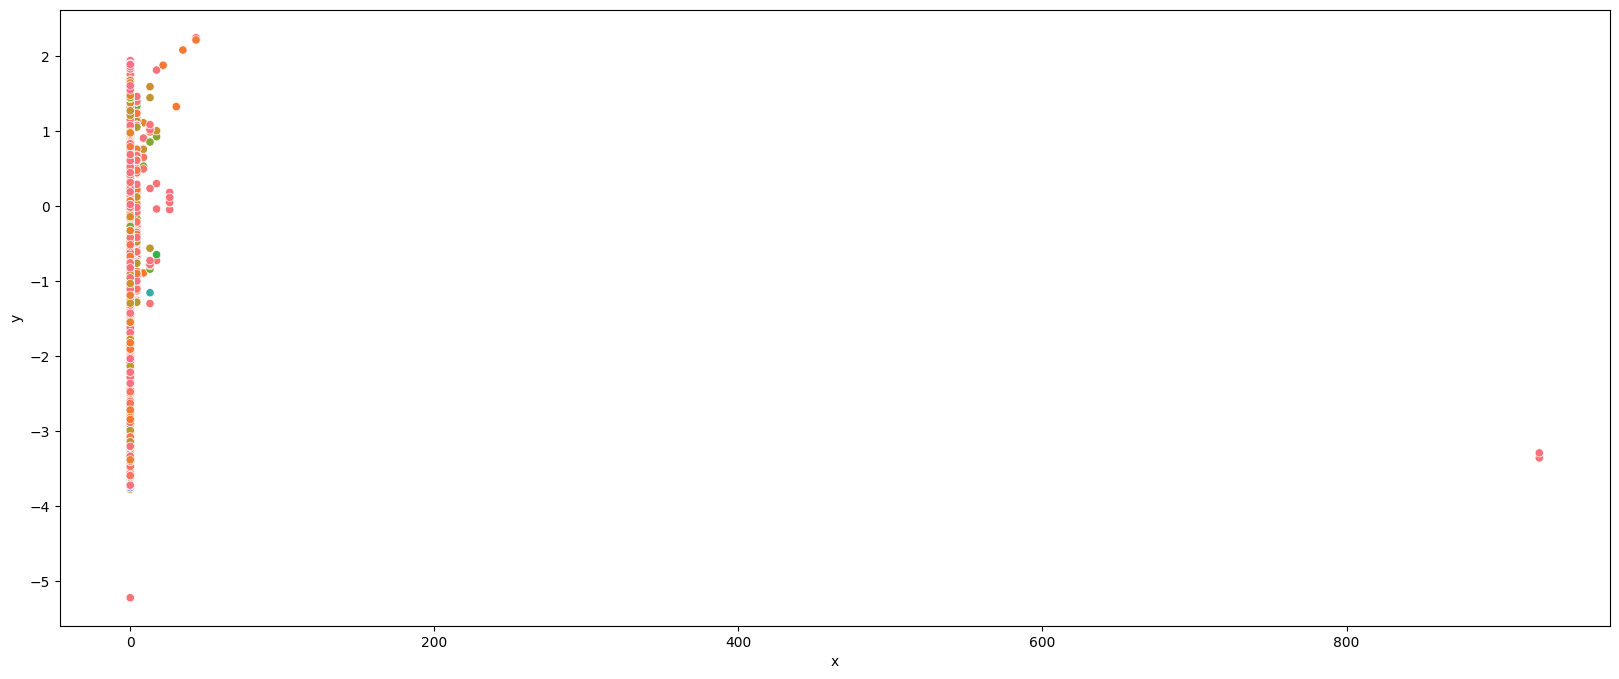

In [50]:
# px.scatter(
#     df.with_columns(
#         x=pl.col('vetor').cast(pl.List).list.first(),
#         y=pl.col('vetor').cast(pl.List).list.last()
#     ).to_pandas(),
#     x='x',
#     y='y',
#     color='artType',
#     hover_name='id'
# )

fig = plt.figure(figsize=(20, 8))
sns.scatterplot(
    data = df.with_columns(
         x=pl.col('vetor').cast(pl.List).list.first(),
         y=pl.col('vetor').cast(pl.List).list.last()
     ).to_pandas(),
    x='x',
    y='y',
    hue='artType',
    legend=False
)

fig.show()

del fig

Os dados de `artClass` realmente não expressam muito.

Vamos voltar atrás e removê-los do dataframe.

In [51]:
df = df.drop('artClass', 'vetor')

df.head()

id,pubName,pubDate,artCategory,artType,texto
str,str,date,str,str,str
"""530_20191021_12117676""","""DO3""",2019-10-21,"""Ministério da Defesa/Comando d…","""Edital""","""EDITAL de 18 de outubro de 201…"
"""529_20240202_21368869""","""DO2""",2024-02-02,"""Ministério da Defesa/Comando d…","""Portaria""","""PORTARIA Nº 32- CMSE/C EX, DE …"
"""529_20210722_13685130""","""DO2""",2021-07-22,"""Ministério da Defesa/Comando d…","""Portaria""","""PORTARIA Nº 510-DCIPAS/SPC, DE…"
"""10814638""","""DO3""",2018-06-07,"""Ministério da Defesa/Comando d…","""Aviso de Licitação-Pregão""","""AVISO DE LICITAÇÃO PREGÃO ELET…"
"""530_20200803_12824228""","""DO3""",2020-08-03,"""Ministério da Defesa/Comando d…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 14/2020…"


E quanto ao `texto`, que é a variável mais importante, objeto desta análise?
Pela descrição do dataframe, não existem valores nulos de texto, porém como já vimos na variável `highlight`, é possível que valores nulos estejam passando desapercebidos por serem representados por strings vazias. Vamos verificar se esse é o caso:

In [52]:
(
    df
    .group_by(
        pl.col('texto').str.len_chars().alias('qtd_caracteres')
    )
    .agg(
        pl.len().alias('qtd_textos')
    )
    .sort(
        'qtd_caracteres',
        descending=False
    )
    .show(limit=20)
)

qtd_caracteres,qtd_textos
u32,u32
7,1
14,1
23,3
36,1
43,3
48,4
53,1
58,1
65,1


Não temos nenhum texto vazio, mas temos vários textos menores do que 140 (ao invés de uma publicação no DOU, poderia ser um tweet).

Vejamos se isso faz sentido.

In [53]:
(
    df
    .filter(
        pl.col('texto').str.len_chars() < 140
    )
    .sort(
        pl.col('texto').str.len_chars()
    )
    .show(limit=-1, fmt_str_lengths=140)
)

id,pubName,pubDate,artCategory,artType,texto
str,str,date,str,str,str
"""515_20220425_14448914""","""DO1""",2022-04-25,"""Ministério da Defesa/Comando da Marinha/Empresa Gerencial de Projetos Navais""","""Balanço Patrimonial""","""Balanço"""
"""530_20230102_20222954.xml""","""DO3""",2023-01-02,"""Ministério da Defesa/Comando do Exército/Comando Militar do Oeste/18ª Brigada de Infantaria de Pantanal/2ª Companhia de Fronteira""","""Retificação""","""DE RETIFICACAO"""
"""515_20220217_14273514""","""DO1""",2022-02-17,"""Ministério da Defesa/Comando da Marinha/Comando de Operações Navais/7º Distrito Naval/Capitania Fluvial de Goiás""","""Ato Normativo""","""Anexo B Anexo B ANEXO B"""
"""515_20220217_14273515""","""DO1""",2022-02-17,"""Ministério da Defesa/Comando da Marinha/Comando de Operações Navais/7º Distrito Naval/Capitania Fluvial de Goiás""","""Ato Normativo""","""Anexo C Anexo C ANEXO C"""
"""515_20220217_14273518""","""DO1""",2022-02-17,"""Ministério da Defesa/Comando da Marinha/Comando de Operações Navais/7º Distrito Naval/Capitania Fluvial de Goiás""","""Ato Normativo""","""Anexo A Anexo A ANEXO A"""
"""515_20210305_13334306""","""DO1""",2021-03-05,"""Ministério da Defesa/Comando da Marinha/Empresa Gerencial de Projetos Navais""","""Balanço Patrimonial""","""Empresa Gerencial de Projetos Navais"""
"""530_20230524_20621662.xml""","""DO3""",2023-05-24,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Divisão de Exército/Artilharia Divisionária da 1ª Divisão de Exército/2…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 2/2023 - UASG 160272"""
"""530_20230524_20621646.xml""","""DO3""",2023-05-24,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Divisão de Exército/Artilharia Divisionária da 1ª Divisão de Exército/2…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 2/2023 - UASG 160272"""
"""530_20230524_20621664.xml""","""DO3""",2023-05-24,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Divisão de Exército/Artilharia Divisionária da 1ª Divisão de Exército/2…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 2/2023 - UASG 160272"""


Parece que existe um padrão. Com exceção de alguns erros óbvios, os textos curtos são retificações ou extratos.

In [54]:
(
    df
    .filter(pl.col('texto').str.len_chars() < 140)
    .group_by('pubName', 'artType')
    .agg(
        pl.len().alias('qtd_por_tipo'),
        pl.col('texto').str.len_chars().mean().alias('tamanhoMedio')
    )
    .sort('tamanhoMedio')
)

pubName,artType,qtd_por_tipo,tamanhoMedio
str,str,u32,f64
"""DO1""","""Ato Normativo""",3,23.0
"""DO3""","""Extrato de Contrato""",5,45.0
"""DO3""","""Extrato de Nota de Empenho""",1,53.0
"""DO1""","""Balanço Patrimonial""",5,61.8
"""DO3""","""Extrato de Termo Aditivo""",7,84.285714
"""DO3""","""Extrato de Apostilamento""",208,111.168269
"""DO3""","""Retificação""",12,113.916667
"""DO3""","""Ato""",1,117.0
"""DO3""","""Aviso de Licitação-Leilão""",1,127.0


Aproveitando o ensejo, vamos visualizar como está distribuído o tamanho dos textos pelo tipo de documentos e pelos tipos de publicações.

C:\Users\INTEL\AppData\Local\Temp\ipykernel_35060\1089698771.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


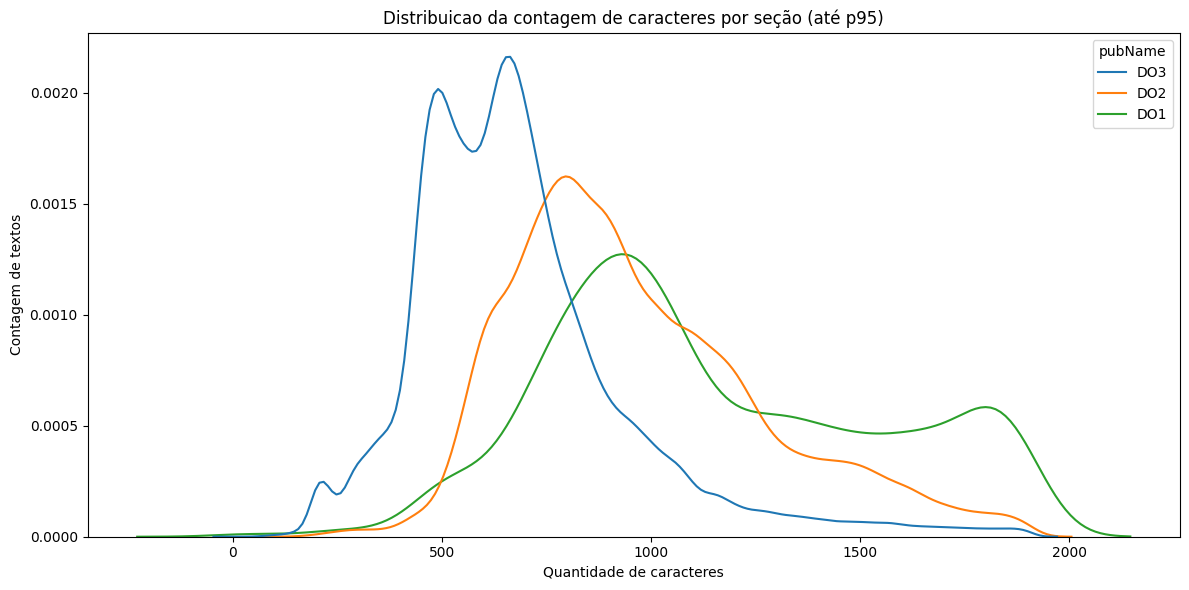

In [55]:
tamanho_pd = (
    df.select(
        pl.col("pubName"),
        pl.col("texto").str.len_chars().alias("tamanho")
    )
).to_pandas()

limite_superior = tamanho_pd["tamanho"].quantile(0.95)
plot_data = tamanho_pd[tamanho_pd["tamanho"] <= limite_superior]

fig = plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=plot_data,
    x="tamanho",
    hue="pubName",
    common_norm=False,
    fill=False,
    bw_adjust=1,
)

plt.title("Distribuicao da contagem de caracteres por seção (até p95)")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Contagem de textos")
plt.tight_layout()
fig.show()

del tamanho_pd, limite_superior, plot_data, fig

Os documentos da Seção 1 são normalmente mais extensos, os da Seção 3 são, na sua maioria, concentrados em torno dos 500 caracteres por documento.

C:\Users\INTEL\AppData\Local\Temp\ipykernel_35060\947927771.py:16: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(
C:\Users\INTEL\AppData\Local\Temp\ipykernel_35060\947927771.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


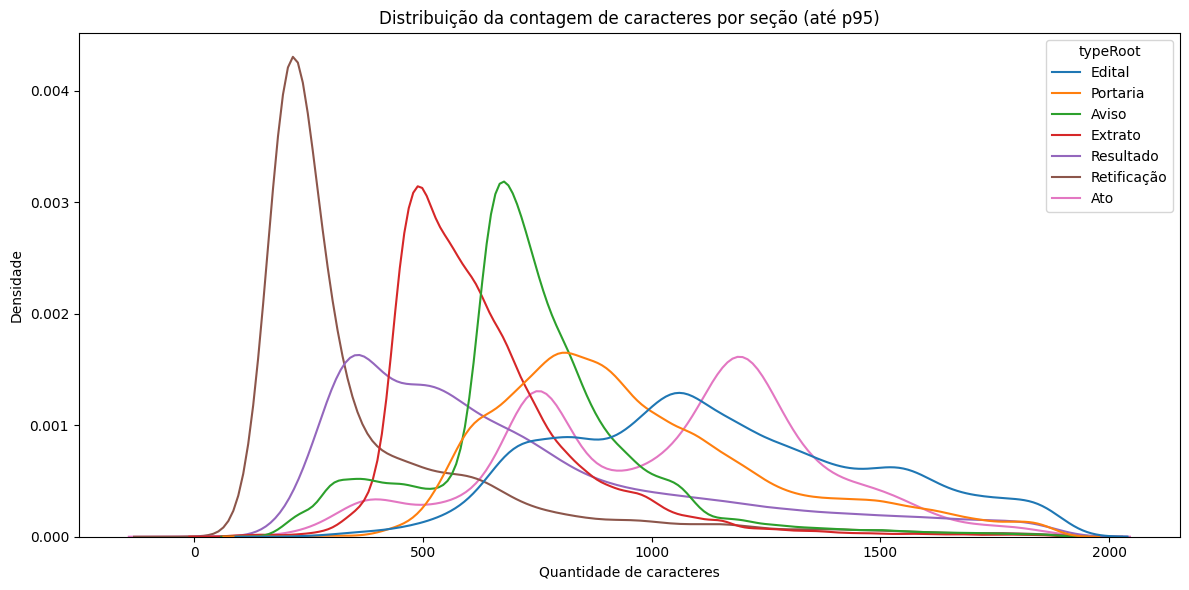

In [56]:
doc_comuns = (
    df
    .with_columns(
        typeRoot=pl.col("artType").str.split(' ').list.first()
    )
    .group_by('typeRoot')
    .agg(pl.len())
    .filter(pl.col('len') > 0.01*df.height)
)

tamanho_pd = (
    df
    .with_columns(
        typeRoot=pl.col("artType").str.split(' ').list.first()
    )
    .filter(
        pl.col('typeRoot').is_in(doc_comuns.select('typeRoot').to_series())
    )
    .select(
        pl.col("typeRoot"),
        pl.col("texto").str.len_chars().alias("tamanho")
    )
).to_pandas()

limite_superior = tamanho_pd["tamanho"].quantile(0.95)
plot_data = tamanho_pd[tamanho_pd["tamanho"] <= limite_superior]

fig = plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=plot_data,
    x="tamanho",
    hue="typeRoot",
    common_norm=False,
    fill=False,
    bw_adjust=1,
)

plt.title("Distribuição da contagem de caracteres por seção (até p95)")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Densidade")
plt.tight_layout()
fig.show()

del doc_comuns, tamanho_pd, limite_superior, plot_data, fig

Já o tamanho dos textos por tipo de documento se distribui conforme o gráfico acima.

Indisputadamente, Retificações são os menores documentos. O que faz sentido, dado que eles fazem pequenas alterações em textos de documentos já publicados.

Os Resultados têm sua moda próxima dos 400 caracteres, mas o tamanho varia bastante entre os documentos, evidente pela sua curva aparentemente platicúrtica.

Os Extratos são os próximos dos documentos curtos, com sua média girando em torno de 500 caracteres.

### 2.4.3. Valores duplicados

Verificação para existência de dados duplicados.

In [57]:
df.filter(df.is_duplicated()).shape[0]

0

Não há dados duplicados, mas só pra garantir:

In [58]:
df = df.unique()

## 2.5 Visão Geral da Base de Dados

In [59]:
df.shape

(506666, 6)

In [60]:
df.describe()

statistic,id,pubName,pubDate,artCategory,artType,texto
str,str,str,str,str,str,str
"""count""","""506666""","""506666""","""506666""","""506666""","""506666""","""506666"""
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",null,null,"""2022-02-04 04:05:30.935172""",null,null,null
"""std""",null,null,null,null,null,null
"""min""","""10449257""","""DO1""","""2018-03-12""","""Ministério da Defesa/Comando d…","""Acordo Coletivo de Trabalho""","""""BATALHÃO PERIBEBUÍ"" AVISO DE …"
"""25%""",null,null,"""2020-04-14""",null,null,null
"""50%""",null,null,"""2022-01-18""",null,null,null
"""75%""",null,null,"""2023-11-21""",null,null,null
"""max""","""612_20210401_13401898""","""DO3""","""2026-02-27""","""Ministério da Defesa/Comando d…","""Termo de Autorização""","""PORTARIA Nº 73/AMAZUL, DE 5 …"


# 3. Metodologia

Para filtrar e classificar os textos, no intuito de extrair informações, decidi utilizar pouca ou nenhuma biblioteca externa a built-in do python. 

Isso porque a princípio eu criei uma solução muito complexa para classificação dos textos usando o scipy rodando localmente, mas ao tentar rodar o mesmo notebook no google colab, este não dispunha de memória suficiente além de tornar o tempo para execução do notebook inviável.

Assim, vou desenvolver uma solução ad-hoc, focando em encontrar palavras chaves dos documentos, como no caso dos atos de pessoal se notam as palavras que determinam o assunto, em forma de verbos no infinitivo como "NOMEAR", "DEMITIR", "EXONERAR", "CONVOCAR", etc...

O maior limitador para que isso funcione perfeitamente é a própria qualidade dos dados. Veja por exemplo, o caso desta [página de uma publicação](https://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=19/06/2019&jornal=529&pagina=12) de transferência de militares para a reserva remunerada. O primeiro documento, a portaria nº 20, possui o verbo REFORMAR, que dá sentido ao assunto da publicação. No entanto, o verbo é omitido dos próximos quatro documentos, que deduz-se pelo contexto que também versem sobre reforma de militares.

Apesar disso, acredito que a solução funcionará para a maioria dos documentos, não frustando o objetivo primeiro do perfilamento documental das forças.

In [116]:
# import spacy
# !spacy download pt_core_news_sm

# nlp = spacy.load("pt_core_news_sm")

In [62]:
# dou2 = (
#     df
#     .filter(pl.col("pubName") == "DO2")
#     .with_columns(
#         verbs_candidates=pl.col("texto").str.to_lowercase().str.extract_all(r"\b[a-zA-Z]+[aeioô]r\b")
#     )
# )

In [63]:
# (
#     dou2
# )

In [64]:
# [i.pos_ for i in nlp('diretor anular')]

In [65]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# stopwords = []
# for raw in ['bbalet_stopwords_pt.txt', 'fergiemcdowall_stopwords_pt.txt', 'geonetwork-por.txt', 'gh-stopwords-json-pt.txt', 'language-resource-stopwords-variant.txt', 'language-resource-stopwords.txt', 'ranksnl-brazilian.txt', 'ranksnl-portugese.txt', 'stop-words-portugese.txt', 'stopwords-filter-pt.txt']:
#   os.system(f"curl -sSL 'https://github.com/stopwords-iso/stopwords-pt/raw/refs/heads/master/raw/{raw}' > './{raw}'")
#   with open(raw, 'r') as file:
#     stopwords += [i.strip() for i in file.readlines()]
#   os.system(f'rm {raw}')
# stopwords = sorted(set(stopwords))

# vectorizer = TfidfVectorizer(stop_words=stopwords)
# tfidf_matrix = vectorizer.fit_transform(dou2.get_column('verb_likes'))

In [66]:
# import numpy as np

# # 1. Somar colunas direto na matriz sparse
# col_sums = np.array(tfidf_matrix.sum(axis=0)).ravel()

# # 2. Calcular quantil (p995)
# q995 = np.quantile(col_sums, 0.995)

# # 3. Criar máscara de colunas relevantes
# mask = col_sums > q995

# # 4. Filtrar matriz e nomes
# filtered_matrix = tfidf_matrix[:, mask]
# filtered_features = vectorizer.get_feature_names_out()[mask]

# # 5. Só agora converter (bem menor)
# verb_importance = pl.DataFrame(
#     filtered_matrix.toarray(),
#     schema=filtered_features.tolist(),
#     orient="row"
# )

# del col_sums, q995, vectorizer, tfidf_matrix

In [67]:
# verb_importance

In [68]:
# dou2.filter(pl.col('texto').str.to_lowercase().str.contains(r'(decide|resolve):?')).group_by('artType').agg(pl.len()).show(fmt_str_lengths=1500)

In [69]:
# dou2.filter(~pl.col('texto').str.to_lowercase().str.contains(r'(decide|resolve):?')).group_by('artType').agg(pl.len()).show(fmt_str_lengths=1500)

In [70]:
# dou2.filter((~pl.col('texto').str.to_lowercase().str.contains(r'(decide|resolve):?')) & (pl.col('artType')=='Portaria')).show(fmt_str_lengths=1500)

In [71]:
# dou2 = (
#     dou2
#     .with_columns(
#         verbos=pl.col('texto').str.to_lowercase().str.extract_all(r'\b[a-zA-Z]+[aeioô]r\b').list.unique()
#     )
# )

# verb_corpus = dou2.select('verbos').to_series().to_list()

# verb_set = set(np.hstack(dou2.select('verbos').to_series()).tolist())
# verb_set = [i for i in verb_set if nlp(i)[0].pos_ == 'VERB']

# verb_corpus = [[i for i in j if i in verb_set] for j in verb_corpus]

# verb_corpus = [' '.join(i) for i in verb_corpus]

In [72]:
# vectorizer = TfidfVectorizer(stop_words=pt_stopwords)

# tfidf_matrix = vectorizer.fit_transform(verb_corpus)

In [73]:
# print("Vocabulary without stopwords:", vectorizer.get_feature_names_out())
# print("Matrix shape:", tfidf_matrix.shape)

In [74]:
# lista_verbos = list(map(str.lower, np.hstack(dou2.with_columns(
#     verbos=pl.col('texto').str.extract_all(r'\b[a-zA-Z]+[aeioô]r\b')
# ).select('verbos').to_series().to_numpy())))

In [75]:
# dict_verbos = {i:lista_verbos.count(i) for i in set(lista_verbos)}

In [76]:
# (pl.from_dict(dict_verbos)
# .drop('por', 'partir', 'militar', 'contar', 'prestador', 'vigor', 'ter', 'ser', 'complementar', 'auxiliar', 'maior', 'diretor', 'parecer', 'valor', 'major', 'salvador', 'instrutor', 'coordenador', 'aviador', 'carater', 'professor', 'servidor', 'assessor')
# .transpose(include_header=True).sort('column_0', descending=True))

In [126]:
dou2 = (
    df.filter((pl.col('pubName')=='DO2') & (pl.col('artType').is_in(['Portaria', 'Ato Concessório', 'Ato'])) & (~pl.col('texto').str.to_lowercase().str.starts_with(r'.?retificação')))
)

In [119]:
dou2.group_by('artType').agg(pl.len()).sort('len', descending=True)

artType,len
str,u32
"""Portaria""",84167
"""Ato Concessório""",3399
"""Ato""",2711


In [ ]:
(
    dou2
    .with_columns(
        nomeacao=(pl.col('texto').str.to_lowercase().str.contains(r'nomear')),
        exoneracao=(pl.col('texto').str.to_lowercase().str.contains(r'exonerar')),
        concessao=(pl.col('texto').str.to_lowercase().str.contains(r'concede+r')),
        promocao=(pl.col('texto').str.to_lowercase().str.contains(r'promover')),
        prorrogacao=(pl.col('texto').str.to_lowercase().str.contains(r'prorrogar')),
        colocacao=(pl.col('texto').str.to_lowercase().str.contains(r'(colocar|coloca [ao])')),
        designacao=(pl.col('texto').str.to_lowercase().str.contains(r'(designar|design[ao] [ao])')),
        manutencao=(pl.col('texto').str.to_lowercase().str.contains(r'manter')),
        aposentadoria=(pl.col('texto').str.to_lowercase().str.contains(r'aposentar')),
        demissao=(pl.col('texto').str.to_lowercase().str.contains(r'demitir')),
        contratacao=(pl.col('texto').str.to_lowercase().str.contains(r'(contratar|contrata [ao])')),
        reversao=(pl.col('texto').str.to_lowercase().str.contains(r'reverter')),
        alteracao=(pl.col('texto').str.to_lowercase().str.contains(r'alterar')),
        transferencia=(pl.col('texto').str.to_lowercase().str.contains(r'transferir')),
        renovacao=(pl.col('texto').str.to_lowercase().str.contains(r'(renovar|renova [ao])')),
        reforma=(pl.col('texto').str.to_lowercase().str.contains(r'(reformar|reform[ao] [ao])')),
        garantia=(pl.col('texto').str.to_lowercase().str.contains(r'assegurar')),
        dispensa=(pl.col('texto').str.to_lowercase().str.contains(r'dispensar')),
        cancelamento=(pl.col('texto').str.to_lowercase().str.contains(r'cancelar')),
        sem_efeito=(pl.col('texto').str.to_lowercase().str.contains(r'tornar? sem efeito')),
        anulacao=(pl.col('texto').str.to_lowercase().str.contains(r'(anular|anulo [oa])')),
        consideracao=(pl.col('texto').str.to_lowercase().str.contains(r'considerar')),
        agregacao=(pl.col('texto').str.to_lowercase().str.contains(r'agregar')),
        licenciamento=(pl.col('texto').str.to_lowercase().str.contains(r'licenciar')),
        inclusao=(pl.col('texto').str.to_lowercase().str.contains(r'incluir')),
        incorporacao=(pl.col('texto').str.to_lowercase().str.contains(r'incorporar')),
        declaracao=(pl.col('texto').str.to_lowercase().str.contains(r'declarar')),
        revogacao=(pl.col('texto').str.to_lowercase().str.contains(r'revogar')),
        exclusao=(pl.col('texto').str.to_lowercase().str.contains(r'excluir')),
        autorizacao=(pl.col('texto').str.to_lowercase().str.contains(r'autorizar')),
        convocacao=(pl.col('texto').str.to_lowercase().str.contains(r'convocar')),
        tornar_insub=(pl.col('texto').str.to_lowercase().str.contains(r'tornar insubsistente')),
        suspencao=(pl.col('texto').str.to_lowercase().str.contains(r'suspender')),
        reestabelecimento=(pl.col('texto').str.to_lowercase().str.contains(r'ree?stabelecer')),
        cassacao=(pl.col('texto').str.to_lowercase().str.contains(r'cassar')),
        dispor=(pl.col('texto').str.to_lowercase().str.contains(r'passar [àa] disposição')),
        conversao=(pl.col('texto').str.to_lowercase().str.contains(r'converter')),
        cessao2=(pl.col('texto').str.to_lowercase().str.contains(r'\bceder\b')),
        encerramento=(pl.col('texto').str.to_lowercase().str.contains(r'encerrar')),
        fixacao=(pl.col('texto').str.to_lowercase().str.contains(r'fixar')),
        desligamento=(pl.col('texto').str.to_lowercase().str.contains(r'desligar')),
        substituicao=(pl.col('texto').str.to_lowercase().str.contains(r'substituir')),
        retroacao=(pl.col('texto').str.to_lowercase().str.contains(r'retroagir')),
        efetivacao=(pl.col('texto').str.to_lowercase().str.contains(r'efetivar')),
        publicar=(pl.col('texto').str.to_lowercase().str.contains(r'tornar(.+)p[úu]blic[ao]')),
        consignacao=(pl.col('texto').str.to_lowercase().str.contains(r'consignar')),
        reinicio=(pl.col('texto').str.to_lowercase().str.contains(r'reiniciar')),
        acolhimento=(pl.col('texto').str.to_lowercase().str.contains(r'acolher')),
        aplicacao=(pl.col('texto').str.to_lowercase().str.contains(r'aplicar')),
        reintegracao=(pl.col('texto').str.to_lowercase().str.contains(r'reintegrar')),
        interrupcao=(pl.col('texto').str.to_lowercase().str.contains(r'interromper')),
        deferimento=(pl.col('texto').str.to_lowercase().str.contains(r'\bdeferir\b')),
        indeferimento=(pl.col('texto').str.to_lowercase().str.contains(r'indeferir')),
        remocao=(pl.col('texto').str.to_lowercase().str.contains(r'remover')),
        assuncao=(pl.col('texto').str.to_lowercase().str.contains(r'assumir')),
        homologacao=(pl.col('texto').str.to_lowercase().str.contains(r'homologar')),
        aprovacao=(pl.col('texto').str.to_lowercase().str.contains(r'aprovar')),
        instituicao=(pl.col('texto').str.to_lowercase().str.contains(r'instituir')),
        cessao1=(pl.col('texto').str.to_lowercase().str.contains(r'\bcessar\b')),
        delegacao=(pl.col('texto').str.to_lowercase().str.contains(r'delegar')),
        disponibilizacao=(pl.col('texto').str.to_lowercase().str.contains(r'disponibilizar')),
        ratificacao=(pl.col('texto').str.to_lowercase().str.contains(r'ratificar')),
        reconducao=(pl.col('texto').str.to_lowercase().str.contains(r'reconduzir')),
        lotacao=(pl.col('texto').str.to_lowercase().str.contains(r'lotar')),
        encostamento=(pl.col('texto').str.to_lowercase().str.contains(r'encostar')),
        reabilitacao=(pl.col('texto').str.to_lowercase().str.contains(r'reabilitar')),
        determinacao=(pl.col('texto').str.to_lowercase().str.contains(r'determinar')),
        classificacao=(pl.col('texto').str.to_lowercase().str.contains(r'classificar')),
        estabelecimento=(pl.col('texto').str.to_lowercase().str.contains(r'estabelecer')),
        notificacao=(pl.col('texto').str.to_lowercase().str.contains(r'notificar')),
        credenciamento=(pl.col('texto').str.to_lowercase().str.contains(r'credenciar')),
        constituicao=(pl.col('texto').str.to_lowercase().str.contains(r'constituir')),
        enquadramento=(pl.col('texto').str.to_lowercase().str.contains(r'enquadrar')),
        revisao=(pl.col('texto').str.to_lowercase().str.contains(r'\brever\b')),
        atribuicao=(pl.col('texto').str.to_lowercase().str.contains(r'atribuir')),
        retificacao=(pl.col('texto').str.to_lowercase().str.contains(r'(retificar|onde se[\s\-]l[êe])')),
        empossamento=(pl.col('texto').str.to_lowercase().str.contains(r'empossar')),
        criacao=(pl.col('texto').str.to_lowercase().str.contains(r'criar')),
        rescisao=(pl.col('texto').str.to_lowercase().str.contains(r'rescindir')),
        reconhecimento=(pl.col('texto').str.to_lowercase().str.contains(r'reconhecer')),
        retorno=(pl.col('texto').str.to_lowercase().str.contains(r'retornar')),
        a_pedido=(pl.col('texto').str.to_lowercase().str.contains(r'a pedido')),
        ex_officio=(pl.col('texto').str.to_lowercase().str.contains(r'ex[\-\s]off?[íi]cio')),
        apuracao=(pl.col('texto').str.to_lowercase().str.contains(r'apurar os fatos')),
        expedicao=(pl.col('texto').str.to_lowercase().str.contains(r'expedir')),
        promo_antig=(pl.col('texto').str.to_lowercase().str.contains(r'por antiguidade')),
        promo_merit=(pl.col('texto').str.to_lowercase().str.contains(r'por merecimento')),
        apostilamento=(pl.col('texto').str.to_lowercase().str.contains(r'apostilar')),
        ttc=(pl.col('texto').str.to_lowercase().str.contains(r'exercer(\sa)? tarefa')),
        dano_erario=(pl.col('texto').str.to_lowercase().str.contains(r'(dano|ressarcimento) ao er[áa]rio')),
        ressarcimento=(pl.col('texto').str.to_lowercase().str.contains(r'ressarci(r|mento)')),
        missao_exterior=(pl.col('texto').str.to_lowercase().str.contains(r'missão no exterior')),
        viuva=(pl.col('texto').str.to_lowercase().str.contains(r'vi[úu]va')),
        passa_vigorar=(pl.col('texto').str.to_lowercase().str.contains(r'passa a vigorar')),
        beneficiario=(pl.col('texto').str.to_lowercase().str.contains(r'beneficiári[ao]s?')),
        extincao=(pl.col('texto').str.to_lowercase().str.contains(r'extinguir')),
        decisao_judicial=(pl.col('texto').str.to_lowercase().str.contains(r'decisão judicial')),
        ltip=(pl.col('texto').str.to_lowercase().str.contains(r'(licença para tratar de assunto particular|ltip)')),
        permanencia_rr=(pl.col('texto').str.to_lowercase().str.contains(r'permanência na reserva remunerada')),
        afastamento=(pl.col('texto').str.to_lowercase().str.contains(r'afastar')),
        indicacao=(pl.col('texto').str.to_lowercase().str.contains(r'indicar')),
        dilatacao=(pl.col('texto').str.to_lowercase().str.contains(r'dilatar')),
        validacao=(pl.col('texto').str.to_lowercase().str.contains(r'\b(validar|convalidar)')),
        habilitacao=(pl.col('texto').str.to_lowercase().str.contains(r'habilitar')),
    )
    .filter(
        ~pl.any_horizontal(cs.boolean())
    )
    .select('id', 'texto')
    .show(limit=-1, fmt_str_lengths=2000)
)

id,texto
str,str
"""529_20241121_22152504""","""PORTARIA Nº 116 - SSAPC - SAP- SVP/1-RIO, DE 14 DE NOVEMBRO DE 2024 O COMANDANTE DA 1ª REGIÃO MILITAR, no uso da competência que lhe foi atribuída pela Portaria nº 1700 do Comandante de Exército, de 08 de dezembro de 2017, publicada no Boletim do Exército nº 50, de 15 de dezembro de 2017, e tendo em vista o que consta do Processo nº 1303551, resolve: qualidade de cônjuge do instituidor civil aposentado, GERALDO MIGUEL DO NASCIMENTO, matrícula SIAPE n° 74.250, falecido em 1º de agosto de 2024, tendo como referência atual o cargo de Agente de Atividades de Agropecuária, enquadrado no Plano Geral de Cargos do Poder Executivo; com fundamento no inciso I do Art 3º da Portaria SGP/SEDGG/ME nº 4645, de 24 de maio de 2022, combinado com o Art. 217: inciso I e Art. 222: inciso VII - alínea (b), item 6, ambos da Lei nº 8.112, de 11 de dezembro de 1990, e em conformidade com a nova redação dada pela Lei nº 13.135, de 17 de junho de 2015, sendo o valor do benefício calculado em conformidade com o artigo nº 23 da Emenda Constitucional nº 103, de 12 de novembro de 2019, com percentual de 60% (sessenta por cento) (1ª RM - SAP/1-Rio). Art 2º Esta Portaria tem sua vigência e seus efeitos financeiros a vigorar em 1º de agosto de 2024, data do óbito do instituidor, conforme Art. 219: inciso I da Lei nº 13.846 de 18 de junho de 2019. Gen Div CARLOS DUARTE PONTUAL DE LEMOS"""
"""529_20200311_12495228""","""PORTARIA Nº 126 - DCIPAS/31.2, DE 9 DE MARÇO DE 2020 O DIRETOR DE CIVIS, INATIVOS, PENSIONISTAS E ASSISTÊNCIA SOCIAL, no uso da competência que lhe foi subdelegada pela Portaria nº 192-DGP, de 1º de outubro de 2015, e de acordo com o inciso I do Art 96 da Lei nº 6.880, de 9 de dezembro de 1980, resolve: <p> 2º Sgt QE (Idt 020382714-2) GILBERTO EMILIO MARAFON; 2º Sgt QE (Idt 019544813-9) HENRIQUE BARCELOS; 2º Sgt QE (Idt 020396934-0) JAILTON VIEIRA RIBEIRO; 2º Sgt QE (Idt 030931774-1) JAIRO LUIZ CABREIRA; 2º Sgt QE (Idt 019577703-2) JOÃO CÉSAR BAPTISTA DA SILVA; 2º Sgt QE (Idt 030981224-6) JOÃO FERNANDO SERPA LUCHO; 2º Sgt QE (Idt 019486153-0) JOÃO XAVIER NEVES DE ANDRADE; 2º Sgt QE (Idt 072518644-9) JOSAFÁ FLORÊNCIO DA SILVA; 2º Sgt QE (Idt 042002214-7) JOSÉ MARCELINO DE FIGUEIREDO; e 2º Sgt QE (Idt 019544173-8) JUACY JOAQUIM DE ANDRADE. Gen Div EDSON SKORA ROSTY"""
"""529_20200311_12495230""","""PORTARIA Nº 128 - DCIPAS/31.2, DE 9 DE MARÇO DE 2020 O DIRETOR DE CIVIS, INATIVOS, PENSIONISTAS E ASSISTÊNCIA SOCIAL, no uso da competência que lhe foi subdelegada pela Portaria nº 192-DGP, de 1º de outubro de 2015, e de acordo com o inciso I do Art 96 da Lei nº 6.880, de 9 de dezembro de 1980, resolve: <p> 2º Sgt QE (Idt 011123924-0) MARCOS ALEXANDRE COSTA; 2º Sgt QE (Idt 019574923-9) MARCUS PAULO MORAES TEIXEIRA; 2º Sgt QE (Idt 092570614-5) MÁRIO DUTRA PAIM; 2º Sgt QE (Idt 127588213-0) NELIVAM CARVALHO DE SENA; 2º Sgt QE (Idt 030935554-3) NILTON CEZAR DA SILVEIRA FERNANDES; 2º Sgt QE (Idt 030978844-6) PAULO SÉRGIO CORRÊA DA ROSA; 2º Sgt QE (Idt 020381614-5) PEDRO LEANDRO DOS SANTOS; 2º Sgt QE (Idt 020406644-3) RENATO NARCISO. 2º Sgt QE (Idt 030902174-9) ROBERTO COSTA PEREIRA; e 2º Sgt QE (Idt 118282543-8) RODRIGO DA SILVA OLIVEIRA GRAMACHO DE CARVALHO. Gen Div EDSON SKORA ROSTY"""
"""529_20230116_20256010.xml""","""PORTARIA-DCEM/DGP/C Ex Nº 4, DE 13 DE JANEIRO DE 2023 O DIRETOR DE CONTROLE DE EFETIVOS E MOVIMENTAÇÕES, no uso da competência que lhe foi subdelegada pela Portaria - DGP/C Ex nº 302, de 30 de novembro de 2021, resolve: 1. OFICIAIS a. Por término da Missão de Instrutor de Defesa Cibernética na Escola de Comunicações do Exército Peruano, no Peru e, em consequência, ter deixado de incidir no inciso I do art. 81, da Lei nº 6.880, de 9 de dezembro de 1980, o Ten Cel Eng (1010954442) ARNALDO MOREIRA DE FARIA, a contar de 20 de dezembro de 2022. b. Por término da Missão de Oficial de Ligação junto ao Centro de Excelência de Fogos do Exército dos EUA (U.S. Army Fires Center of Excellence), nos EUA e,

## 3.1. Identificação das publicações por Força

## 3.2. Padronização

## 3.3. Classificação temática

## 3.4. Critérios de análise

# 4. Análise Exploratória Inicial

## 4.1. Volume total

## 4.2. Distribuição temporal

## 4.3. Distribuição por Força

# 5. Análise Temática

## 5.1. Categorias

## 5.2. Frequência por categoria

## 5.3. Comparação entre Forças

## 5.4. Evolução temporal

# 6. Indicadores e Perfis Institucionais

## 6.1. Indicadores por dimensão

## 6.2. Interpretação comparativa

## 6.3. Síntese dos perfis

# 7. Conclusão

## 7.1. Principais achados

## 7.2. Limitações

## 7.3. Trabalhos futuros